# 145 — 통계 모형 비교: 계절 나이브 · OLS-AR · SARIMA(X) 대 배포 모델

수치 원본은 같은 폴더의 [`RESULTS.md`](./RESULTS.md)이고, 어긋나면 그쪽이 맞다. 이 노트북은
`evaluate.py`가 남긴 지표 parquet을 **그림으로만** 다시 읽는다.

질문은 둘이다.

1. 고전 시계열 모형이 lookup을 이기는가.
2. 같은 시차 정보를 **선형으로만** 쓰면 LightGBM 개선분(+23~25%)의 몇 %가 재현되는가
   → LightGBM의 기여를 "시차 정보 자체"와 "비선형·범주 상호작용"으로 분해한다.

| 계열 | 정의 |
| --- | --- |
| `lookup` | 요일유형×역×시간대 평균(2024 적합). 기준선 |
| `snaive_d7` | 같은 (역,시간대)의 **원본값** 7일 전 |
| `ols_pooled` | 잔차 = β·[lag1d, lagsd, lag7d] 선형회귀, 타깃별 1개 |
| `ols_series` | 위와 같되 (역,시간대,타깃)마다 따로 적합 |
| `sarima_raw` | 원본 시계열 SARIMAX(1,0,1)(0,1,1,7), lookup 미사용 |
| `sarimax_resid` | lookup 잔차 SARIMAX(1,0,0)(1,0,0,7)+상수 |
| `lightgbm` | 배포 아티팩트 `festival_selflag_d1sd_d7_resid_20260913-0340` |

평가는 2025 전체(공통 행 1,954,680 = 98.08%), 구간은 날짜 블록 부트스트랩 1,000회(142 재사용),
발산 처리는 `clip`(학습 구간 실측 최댓값으로 자르고 채점에 포함)이다.

In [1]:
import sys
from pathlib import Path

AI_ROOT = Path.cwd()
while not (AI_ROOT / "app" / "CROWD").exists():
    AI_ROOT = AI_ROOT.parent
sys.path.insert(0, str(AI_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from DATA_ENGINE.eda import figstyle

figstyle.apply(inline=True)

VAL = AI_ROOT / "data" / "CROWD" / "interim" / "validation" / "stat_model_check"
PROCESSED = AI_ROOT / "data" / "CROWD" / "processed"

a = pd.read_parquet(VAL / "eval_table_A_lookup_대비_개선율_CI.parquet")
b = pd.read_parquet(VAL / "eval_table_B_lightgbm_쌍차이.parquet")
c = pd.read_parquet(VAL / "eval_table_C_재현율.parquet")
d = pd.read_parquet(VAL / "eval_table_D_92표본_점추정.parquet")
f = pd.read_parquet(VAL / "eval_table_F_발산처리_적용행.parquet")
g = pd.read_parquet(VAL / "eval_table_G_제약해제_변형_비교.parquet")
e_path = VAL / "eval_table_E_등급_일치율.parquet"
e = pd.read_parquet(e_path) if e_path.exists() else None

ORDER = ["snaive_d7", "ols_pooled", "ols_series", "sarima_raw", "sarimax_resid", "lightgbm"]
TARGETS = ["boarding", "alighting"]
KOR = {"boarding": "승차", "alighting": "하차"}

tot = a[a["axis"] == "전체"]
print(f"발산 처리: {f['mode'].unique()[0]} · 경계 "
      + " · ".join(f"{t} [0, {f[f.target == t]['상한(2024 실측 최댓값)'].iloc[0]:,.0f}]" for t in TARGETS))
print(f"평가 행 {tot['n_rows'].max():,} · 날짜 {tot['n_dates'].max()}일 · 계열 {len(ORDER)}개")
print(f"등급 표: {'있음' if e is not None else '없음(evaluate.py --grades 필요)'}")

발산 처리: clip · 경계 boarding [0, 17,788] · alighting [0, 20,476]
평가 행 1,954,680 · 날짜 358일 · 계열 6개
등급 표: 있음


## 1. lookup 대비 개선율 — 전체 축

막대는 점추정, 오차막대는 날짜 블록 부트스트랩 95% CI다. 0 아래면 lookup보다 나쁘다.

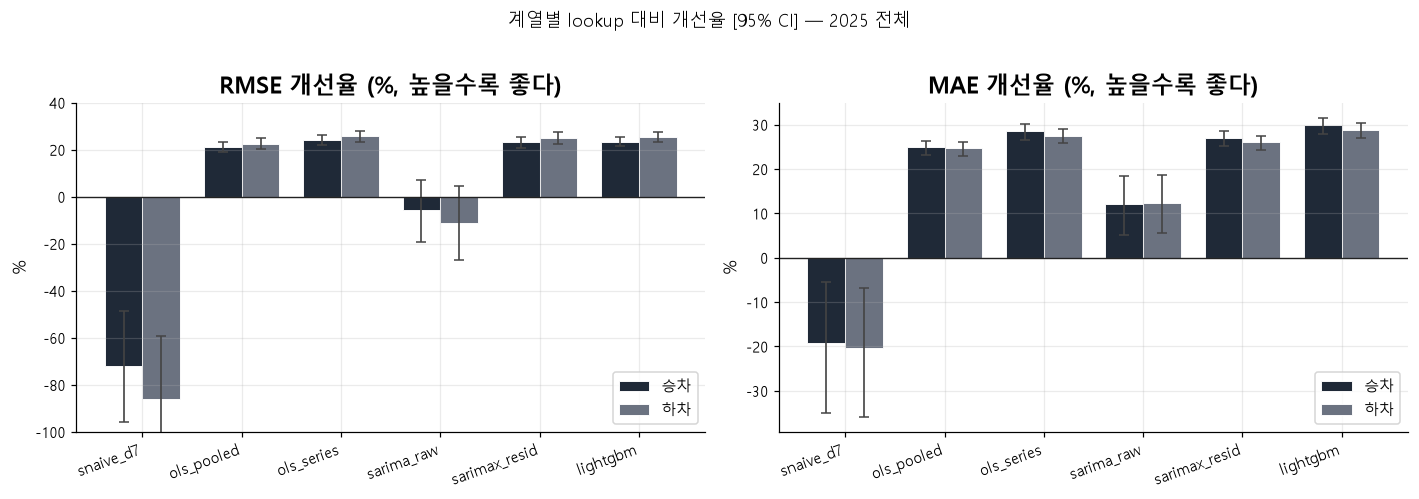

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4), sharey=False)
x = np.arange(len(ORDER))
width = 0.38

for ax, metric in zip(axes, ["RMSE", "MAE"]):
    for i, t in enumerate(TARGETS):
        sub = tot[tot["target"] == t].set_index("series").reindex(ORDER)
        point = sub[f"{metric}_개선율_%"].to_numpy()
        lo = point - sub[f"{metric}_CI_low"].to_numpy()
        hi = sub[f"{metric}_CI_high"].to_numpy() - point
        color = figstyle.PALETTE_NEUTRAL[i]
        ax.bar(x + (i - 0.5) * width, point, width, label=KOR[t], color=color,
               edgecolor="white", linewidth=0.6)
        ax.errorbar(x + (i - 0.5) * width, point, yerr=[lo, hi], fmt="none",
                    ecolor="#444", elinewidth=1.1, capsize=3)
    ax.axhline(0, color="#222", linewidth=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(ORDER, rotation=20, ha="right")
    ax.set_title(f"{metric} 개선율 (%, 높을수록 좋다)")
    ax.set_ylabel("%")
    ax.legend(loc="lower right")

axes[0].set_ylim(-100, 40)
fig.suptitle("계열별 lookup 대비 개선율 [95% CI] — 2025 전체", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "stat_model_improvement")

## 2. LightGBM 개선분 재현율 — 선형으로 얼마나 따라가나

`개선율_계열 ÷ 개선율_lightgbm`. 100%면 배포 모델과 같은 개선폭이라는 뜻이다.

                         재현율_RMSE_%  재현율_MAE_%
series        target                          
snaive_d7     boarding       -307.1      -64.0
              alighting      -339.6      -70.6
ols_pooled    boarding         90.6       83.1
              alighting        89.0       85.8
ols_series    boarding        102.5       95.1
              alighting       101.2       95.9
sarima_raw    boarding        -24.8       40.5
              alighting       -43.3       43.0
sarimax_resid boarding         98.9       90.1
              alighting        98.6       90.6


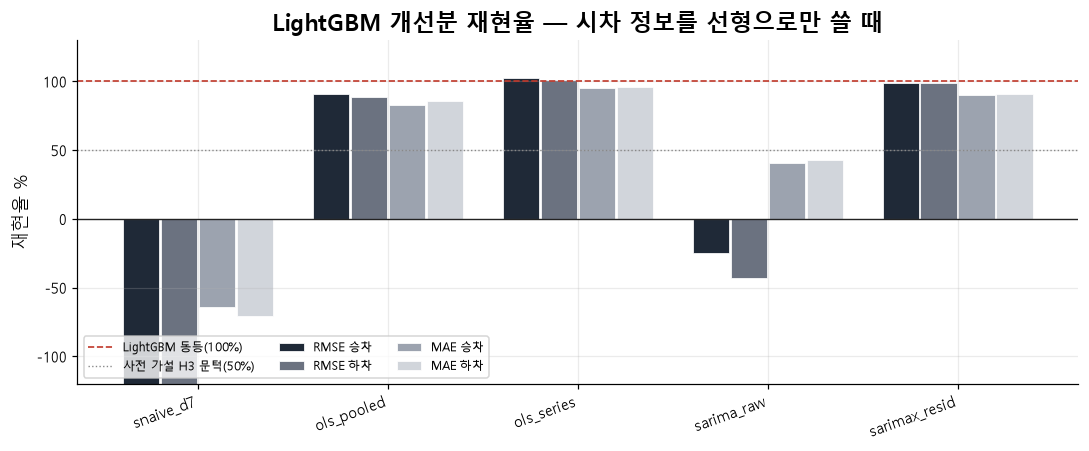

In [3]:
rep = c[c["series"].isin(ORDER)].copy()
piv = rep.pivot(index="series", columns="target", values=["재현율_RMSE_%", "재현율_MAE_%"])
piv = piv.reindex([s for s in ORDER if s in piv.index])

fig, ax = plt.subplots(figsize=(10, 4.2))
xx = np.arange(len(piv))
for i, (metric, label) in enumerate([("재현율_RMSE_%", "RMSE"), ("재현율_MAE_%", "MAE")]):
    for j, t in enumerate(TARGETS):
        pos = xx + (i * 2 + j - 1.5) * 0.2
        ax.bar(pos, piv[(metric, t)].to_numpy(), 0.19,
               label=f"{label} {KOR[t]}", color=figstyle.PALETTE_NEUTRAL[i * 2 + j],
               edgecolor="white", linewidth=0.5)
ax.axhline(100, color="#C0392B", linewidth=1.1, linestyle="--", label="LightGBM 동등(100%)")
ax.axhline(50, color="#888", linewidth=0.9, linestyle=":", label="사전 가설 H3 문턱(50%)")
ax.axhline(0, color="#222", linewidth=0.9)
ax.set_xticks(xx)
ax.set_xticklabels(piv.index, rotation=20, ha="right")
ax.set_ylim(-120, 130)
ax.set_ylabel("재현율 %")
ax.set_title("LightGBM 개선분 재현율 — 시차 정보를 선형으로만 쓸 때")
ax.legend(ncol=3, fontsize=8, loc="lower left")
fig.tight_layout()
figstyle.save(fig, "stat_model_reproduction")

print(rep.set_index(["series", "target"])[["재현율_RMSE_%", "재현율_MAE_%"]].round(1).to_string())

## 3. LightGBM과의 쌍 차이 — 어디서 갈리나

양수는 계열이 LightGBM보다 낫다는 뜻이다. 점은 점추정, 막대는 95% CI.
판정 기준은 "전체 RMSE·MAE 하한 > −2%p **그리고** 어느 호선·요일유형도 2%p 넘게 악화 없음"이다.

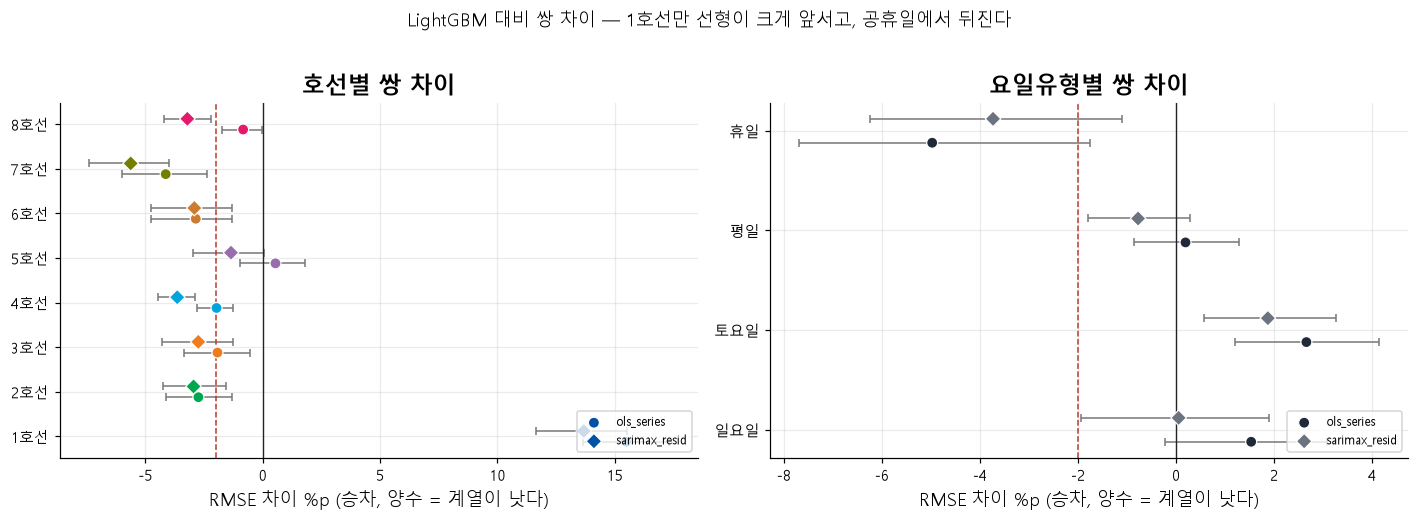

In [4]:
CAND = ["ols_series", "sarimax_resid"]
DIFF = "point_diff_RMSE_%p(계열-LightGBM)"

fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, axis_name in zip(axes, ["호선", "요일유형"]):
    sub = b[(b["axis"] == axis_name) & (b["series"].isin(CAND)) & (b["target"] == "boarding")]
    groups = sorted(sub["group"].unique())
    yy = np.arange(len(groups))
    for i, s in enumerate(CAND):
        part = sub[sub["series"] == s].set_index("group").reindex(groups)
        point = part[DIFF].to_numpy()
        lo = point - part["diff_RMSE_CI_low"].to_numpy()
        hi = part["diff_RMSE_CI_high"].to_numpy() - point
        colors = ([figstyle.LINE_COLORS.get(g, "#666") for g in groups]
                  if axis_name == "호선" else [figstyle.PALETTE_NEUTRAL[i]] * len(groups))
        ax.errorbar(point, yy + (i - 0.5) * 0.24, xerr=[lo, hi], fmt="none",
                    ecolor="#777", elinewidth=1.0, capsize=2.5)
        ax.scatter(point, yy + (i - 0.5) * 0.24, s=52, c=colors,
                   marker="o" if i == 0 else "D", edgecolor="white", linewidth=0.8,
                   label=s, zorder=3)
    ax.axvline(0, color="#222", linewidth=0.9)
    ax.axvline(-2, color="#C0392B", linewidth=1.0, linestyle="--")
    ax.set_yticks(yy)
    ax.set_yticklabels(groups)
    ax.set_xlabel("RMSE 차이 %p (승차, 양수 = 계열이 낫다)")
    ax.set_title(f"{axis_name}별 쌍 차이")
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("LightGBM 대비 쌍 차이 — 1호선만 선형이 크게 앞서고, 공휴일에서 뒤진다", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "stat_model_paired_slices")

## 4. 정상성·가역성 제약 — 발산이 RMSE를 지배한다

제약을 끈 판(`_noenf`)은 늦게 개통한 역 하나(암사역사공원 2810, 패널이 2024-07-31 시작)에서
개루프 전파로 예측이 1e25~1e143까지 튄다. 적합 자체는 성공으로 잡혀 실패 집계에 걸리지 않는다.

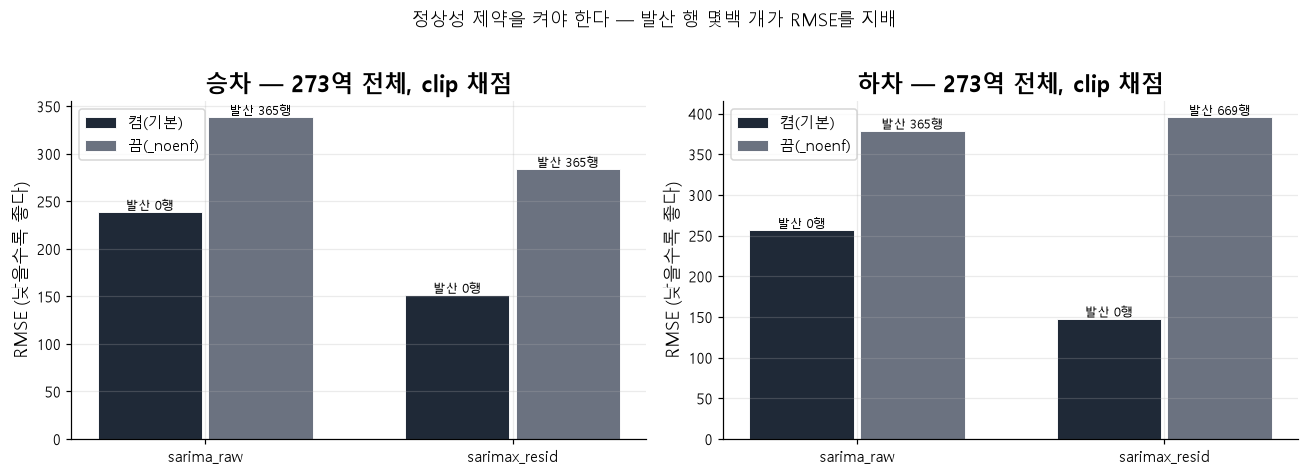

In [5]:
gg = g.copy()
gg["제약"] = np.where(gg["variant"].str.contains("noenf"), "끔(_noenf)", "켬(기본)")
gg["사양"] = gg["variant"].str.replace("_noenf_sample", "", regex=False).str.replace("_noenf", "", regex=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
for ax, t in zip(axes, TARGETS):
    sub = gg[gg["target"] == t]
    specs = ["sarima_raw", "sarimax_resid"]
    xx = np.arange(len(specs))
    for i, state in enumerate(["켬(기본)", "끔(_noenf)"]):
        part = sub[sub["제약"] == state].set_index("사양").reindex(specs)
        bars = ax.bar(xx + (i - 0.5) * 0.36, part["RMSE"].to_numpy(), 0.34, label=state,
                      color=figstyle.PALETTE_NEUTRAL[i], edgecolor="white", linewidth=0.6)
        for rect, n in zip(bars, part["발산행(상한초과)"].to_numpy()):
            ax.annotate(f"발산 {int(n):,}행", (rect.get_x() + rect.get_width() / 2, rect.get_height()),
                        ha="center", va="bottom", fontsize=8)
    ax.set_xticks(xx)
    ax.set_xticklabels(specs)
    ax.set_ylabel("RMSE (낮을수록 좋다)")
    ax.set_title(f"{KOR[t]} — 273역 전체, clip 채점")
    ax.legend()

fig.suptitle("정상성 제약을 켜야 한다 — 발산 행 몇백 개가 RMSE를 지배", y=1.02)
fig.tight_layout()
_ = figstyle.save(fig, "stat_model_enforce")

## 5. 발산 사례 — 역 2810의 한 슬롯

같은 역·같은 슬롯에서 제약을 끈 예측만 로그 축 밖으로 달아난다. 실측은 수백 명 규모다.

발산 슬롯: 15-16 (제약 끈 판에서 예측 최댓값이 가장 큰 시리즈)
  제약 켬(기본): 최댓값 453 · 상한(17,788) 초과 0행
  제약 끔(_noenf): 최댓값 1.34e+25 · 상한(17,788) 초과 365행


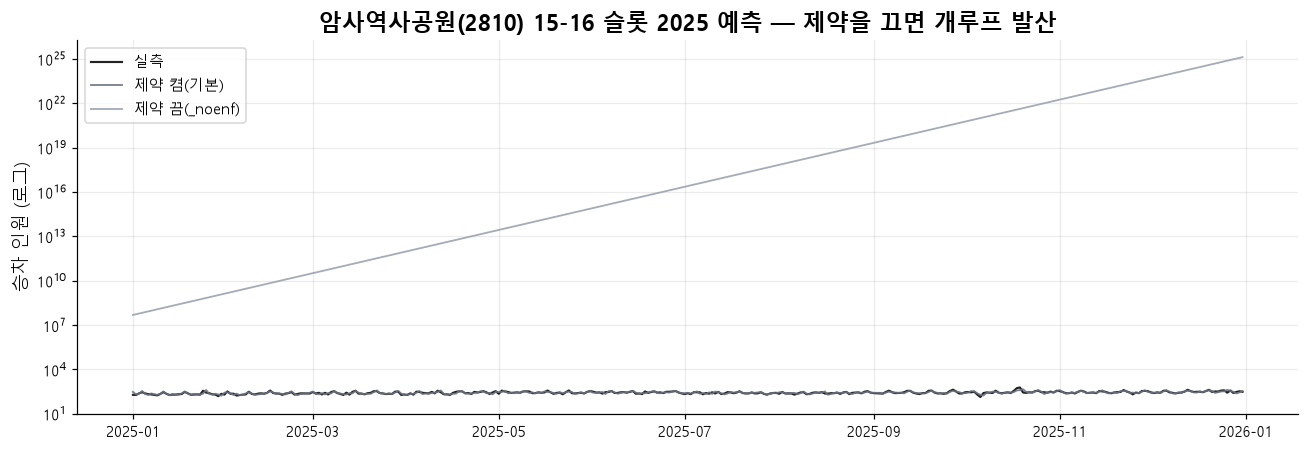

In [6]:
STATION = 2810
KEY = ["date", "station_no", "time_slot"]

# 발산은 특정 (역, 슬롯) 시리즈에서만 난다 — 슬롯을 임의로 고르지 않고 제약 끈 판에서
# 예측이 가장 크게 튄 슬롯을 그대로 집는다.
noenf = pd.read_parquet(VAL / "stat_preds_sarima_raw_noenf.parquet",
                        columns=[*KEY, "boarding_pred"])
noenf = noenf[noenf["station_no"] == STATION]
SLOT = noenf.loc[noenf["boarding_pred"].idxmax(), "time_slot"]

truth = pd.read_parquet(PROCESSED / "crowd_panel_2024_2025.parquet",
                        columns=[*KEY, "station_name", "boarding"])
truth = truth[(truth["station_no"] == STATION) & (truth["time_slot"] == SLOT)
              & (truth["date"] >= "2025-01-01")]
station = truth["station_name"].iloc[0]

series = {}
for name, label in [("sarima_raw", "제약 켬(기본)"), ("sarima_raw_noenf", "제약 끔(_noenf)")]:
    path = VAL / f"stat_preds_{name}.parquet"
    if not path.exists():
        continue
    pr = pd.read_parquet(path, columns=[*KEY, "boarding_pred"])
    pr = pr[(pr["station_no"] == STATION) & (pr["time_slot"] == SLOT)]
    series[label] = truth[KEY].merge(pr, on=KEY, how="left").set_index("date")["boarding_pred"]

fig, ax = plt.subplots(figsize=(12, 4.2))
ax.plot(truth["date"], truth["boarding"].clip(lower=1), color="#222", linewidth=1.4, label="실측")
for i, (label, s) in enumerate(series.items()):
    ax.plot(s.index, s.clip(lower=1), linewidth=1.2, alpha=0.9,
            color=figstyle.PALETTE_NEUTRAL[i + 1], label=label)
ax.set_yscale("log")
ax.set_ylabel("승차 인원 (로그)")
ax.set_title(f"{station}({STATION}) {SLOT} 슬롯 2025 예측 — 제약을 끄면 개루프 발산")
ax.legend()
fig.tight_layout()
figstyle.save(fig, "stat_model_divergence_case")

print(f"발산 슬롯: {SLOT} (제약 끈 판에서 예측 최댓값이 가장 큰 시리즈)")
for label, s in series.items():
    print(f"  {label}: 최댓값 {s.max():,.3g} · 상한(17,788) 초과 {int((s > 17788).sum()):,}행")

## 6. 92 표본은 전체를 대표하지 않는다

같은 계열을 92 표본(50역×30일)과 2025 전체에서 각각 채점한 값이다. 표본에서는
`snaive_d7`까지 LightGBM을 앞서는데 전체 축에서는 −72%다 → 계열 판정은 전체 축 CI로만 한다.

               92 표본  2025 전체
series                       
snaive_d7      31.68   -72.07
ols_pooled     31.31    21.27
ols_series     35.70    24.06
sarima_raw     30.83    -5.82
sarimax_resid  32.65    23.20
lightgbm       26.21    23.46



lookup 절대 RMSE — 92 표본 262.27 vs 전체 196.10 → 표본이 변동 큰 역·날짜에 쏠려 있다


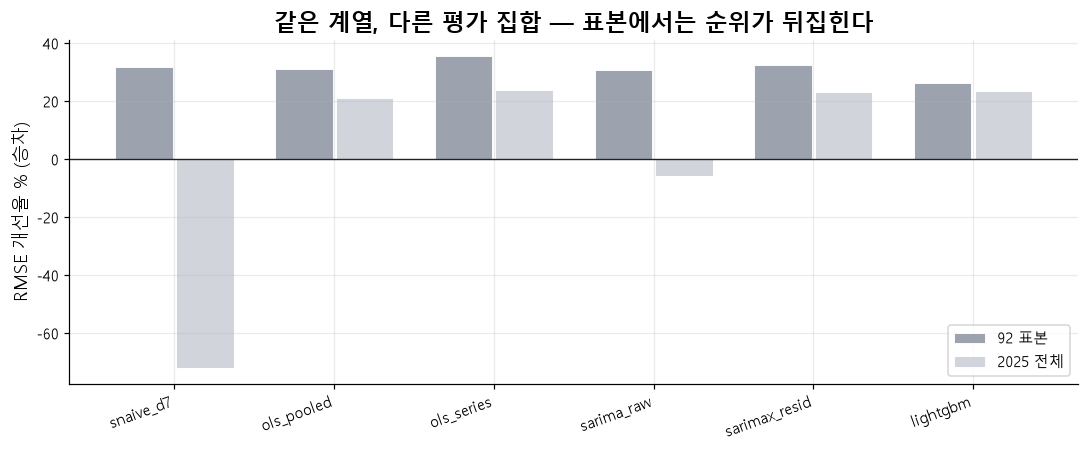

In [7]:
samp = d[d["series"].isin(ORDER) & (d["target"] == "boarding")].set_index("series")
full = tot[tot["target"] == "boarding"].set_index("series")
cmp = pd.DataFrame({
    "92 표본": samp["RMSE_개선율_%"].reindex(ORDER),
    "2025 전체": full["RMSE_개선율_%"].reindex(ORDER),
})

fig, ax = plt.subplots(figsize=(10, 4.2))
xx = np.arange(len(cmp))
for i, col in enumerate(cmp.columns):
    ax.bar(xx + (i - 0.5) * 0.38, cmp[col].to_numpy(), 0.36, label=col,
           color=figstyle.PALETTE_NEUTRAL[i + 2], edgecolor="white", linewidth=0.6)
ax.axhline(0, color="#222", linewidth=0.9)
ax.set_xticks(xx)
ax.set_xticklabels(cmp.index, rotation=20, ha="right")
ax.set_ylabel("RMSE 개선율 % (승차)")
ax.set_title("같은 계열, 다른 평가 집합 — 표본에서는 순위가 뒤집힌다")
ax.legend()
fig.tight_layout()
figstyle.save(fig, "stat_model_sample_bias")

print(cmp.round(2).to_string())
print(f"\nlookup 절대 RMSE — 92 표본 {d[(d.series == 'lookup') & (d.target == 'boarding')]['RMSE'].iloc[0]:.2f}"
      f" vs 전체 196.10 → 표본이 변동 큰 역·날짜에 쏠려 있다")

## 7. 등급 일치율 — 승하차 개선이 등급까지 전달되나

30분 셀 7,649,310개, 배율표는 199 재적합 판. 변환 층은 144·198이 쓴
`dl-resid-check/evaluate_dl.grade_agreement`를 그대로 import한 것이다.

                 cells  등급_일치율_%  보통이상_재현율_%
run                                         
lookup         7649310    95.974      85.042
snaive_d7      7649310    95.449      86.525
ols_pooled     7649310    96.825      89.402
ols_series     7649310    96.960      90.081
sarima_raw     7649310    96.296      88.518
sarimax_resid  7649310    96.925      89.688
lightgbm       7649310    97.044      90.521


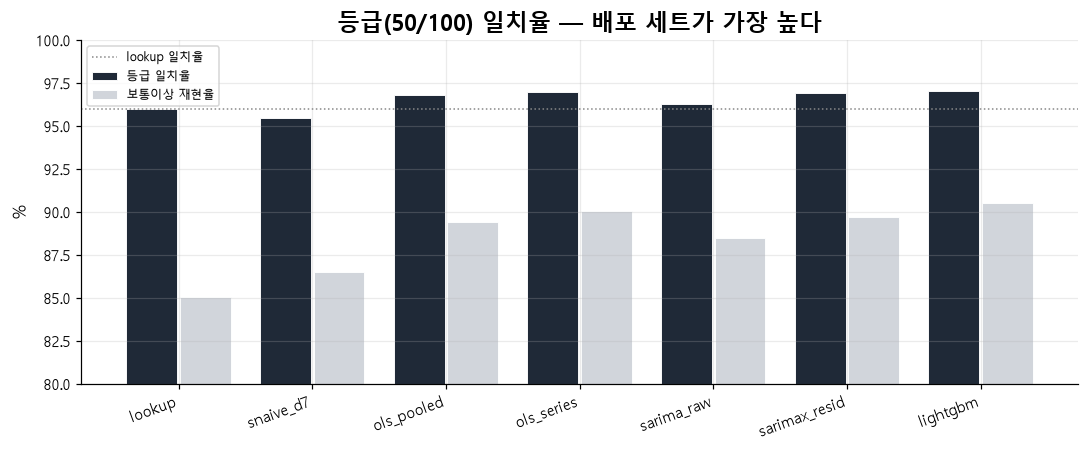

In [8]:
if e is None:
    print("등급 표 없음 — `evaluate.py --grades`로 먼저 만들 것")
else:
    ee = e.set_index("run").reindex(["lookup", *ORDER]).dropna(how="all")
    fig, ax = plt.subplots(figsize=(10, 4.2))
    xx = np.arange(len(ee))
    ax.bar(xx - 0.2, ee["등급_일치율_%"].to_numpy(), 0.38, label="등급 일치율",
           color=figstyle.PALETTE_NEUTRAL[0], edgecolor="white", linewidth=0.6)
    ax.bar(xx + 0.2, ee["보통이상_재현율_%"].to_numpy(), 0.38, label="보통이상 재현율",
           color=figstyle.PALETTE_NEUTRAL[3], edgecolor="white", linewidth=0.6)
    ax.axhline(ee.loc["lookup", "등급_일치율_%"], color="#888", linestyle=":", linewidth=1.0,
               label="lookup 일치율")
    ax.set_xticks(xx)
    ax.set_xticklabels(ee.index, rotation=20, ha="right")
    ax.set_ylim(80, 100)
    ax.set_ylabel("%")
    ax.set_title("등급(50/100) 일치율 — 배포 세트가 가장 높다")
    ax.legend(fontsize=8)
    fig.tight_layout()
    figstyle.save(fig, "stat_model_grades")
    print(ee.round(3).to_string())

## 8. 읽은 것

1. **배포 모델 개선분의 거의 전부가 "시차 정보 자체"에서 나온다.** 시리즈별 선형 AR(`ols_series`)의
   재현율이 RMSE 102.5 / 101.2%, MAE 95.1 / 95.9%다. 비선형·범주 상호작용의 몫은 RMSE에서 사실상 0,
   MAE에서 4~10%p다.
2. **그래도 LightGBM을 유지한다.** 전체 축 쌍차이 기준(하한 > −2%p)은 `ols_series`가 통과하지만
   7호선 −4.13%p·공휴일 −4.97/−6.30%p로 슬라이스 조건에서 탈락하고, 등급 일치율도 배포 세트가
   가장 높다. 배포 모델을 쓰는 근거는 평균 성능이 아니라 **약한 구간이 없다는 점**이다.
3. **1호선만은 선형 시차 모형이 +13~17%p 앞선다.** 요일유형 수정판 패널에서도 재현돼 데이터 판본
   효과가 아니다 — 호선별 교체는 후속 티켓 후보(논의 I-1).
4. **SARIMA는 정상성 제약을 켜야 한다.** 끄면 늦게 개통한 역 하나가 전체 RMSE를 100~250 끌어올린다
   (5절). 제약을 켜면 발산 0건, 수렴 경고도 준다.
5. **계열 판정은 전체 축 CI로만.** 92 표본에서는 계절 나이브까지 배포 모델을 앞선다(6절).